In [1]:
import sys
import numpy as np
import torch
import os
from pathlib import Path
current_dir = Path().resolve()  
ModelBase_path = current_dir.parent/'Model_Base'
sys.path.append(str(ModelBase_path))
print(ModelBase_path)

/home/ubuntu/xty/RSV4HQ/Code/Model_Base


In [2]:
def load_array(data_arrays, batch_size, is_train=True):  #@save

    dataset = torch.utils.data.TensorDataset(*data_arrays)
    return torch.utils.data.DataLoader(dataset, batch_size, shuffle=is_train)


def fun_calDiff(data,y,step):
    if len(data) != len(y):
        raise ValueError("data and y must have the same length")

    indices = [i * step + int(step/2) for i in range(round(len(data) / step))]
    data = [data[i] for i in indices]
    y = [y[i] for i in indices]
    
    U_avi,U_diff,Y_diff = [],[],[]
    for i in range(len(data) - 1):
        if y[i+1] == y[i]:
            raise ValueError("y[i+1] - y[i] is zero, cannot divide by zero")
        U_avi.append((data[i+1] + data[i])/2)
        U_diff.append((data[i+1] - data[i]) / (y[i+1] - y[i]))
        Y_diff.append(y[i+1] - y[i])

    return U_avi,U_diff, Y_diff

def splitData0(data0,step):
    U0 = data0[0]
    H0 = data0[1]
    B0 = data0[int(len(data0)-1)]
    Fr = (U0/np.sqrt(9.81*H0))
    X = B0+2*H0
    R=B0*H0/(B0+2*H0)
    Re = U0*R/1e-6
    dsize = int((len(data0)-2)/2.0)
    Ux0 = data0[2:dsize+2]
    Y = data0[dsize+2:2*dsize+2]
    half_dsize = int(dsize/2.0)
    inValueU = Ux0
    # [:half_dsize]
    inValueY = Y[:half_dsize]

## Data Grade Enhance————
    aver = sum(Ux0)/len(Ux0)
    Uamx_Uaver= max(Ux0)/aver
    inValueU = Ux0/np.average(inValueU)
    U_avi,U_diff,Y_diff = fun_calDiff(Ux0,Y,step)
##——————————————————————————————————

    pin_np1 = np.array(U_avi).reshape(1,-1)
    pin_np2 = np.array(U_diff).reshape(1,-1)
    pin_np3 = np.array(Y_diff).reshape(1,-1)
    pin_np = np.vstack((pin_np1, pin_np2, pin_np3))
    target_np = np.array([U0,H0])
    Z = np.array([U0,H0,B0,Fr,Re,X,R,step,aver,Uamx_Uaver])
    return pin_np, target_np ,Z

def genFeaturesLabels(data_set,step=5,maxh=10,maxFr=0.99,maxHoverB=1.2):
    features,labels,z=[],[],[]
    for data0 in data_set:
        pin_np, target_np ,zi=splitData0(data0,step)
        if zi[9]>1.1:
            continue
        if zi[1]>maxh:
            continue
        if zi[3]>maxFr:
            continue
        if np.log(zi[1]/zi[2])>maxHoverB:
            continue
        features.append(pin_np)
        labels.append(target_np)
        z.append(zi)
    features =  torch.from_numpy(np.array(features))
    labels =  torch.from_numpy(np.array(labels))
    z = torch.from_numpy(np.array(z))
    return features, labels ,z

In [3]:
import random
from Model import ResNetGELU
Data_path = current_dir.parent.parent/'Data/datasets'
file_name = 'Random5000.dat'
file_path = os.path.join(Data_path, file_name)
data_set=np.float32(np.loadtxt(file_path,unpack=True))

def datainput(data_set,batch_size=20,step=20,maxh=10,maxFr=0.99,maxHoverB=1.2):
    data_size=len(data_set)
    random.seed(1)
    train_size = int(data_size*0.8)
    train_cases = random.sample(list(np.arange(0,data_size)), train_size)
    train_cases.sort()
    test_cases = []
    for i in range(data_size):
        if i not in train_cases:
            test_cases.append(i)
    train_iter = load_array((genFeaturesLabels(data_set[train_cases],step,maxh,maxFr,maxHoverB)), batch_size)
    test_iter = load_array((genFeaturesLabels(data_set[test_cases],step,maxh,maxFr,maxHoverB)), batch_size)
    return train_iter,test_iter

In [4]:
def test_plot(train_iter,test_iter,net,cuda=False):

    Q,Q_pred=[],[]
    Q1,Q1_pred=[],[]
    V,V_pred=[],[]
    V1,V1_pred=[],[]
    H,H_pred=[],[]
    H1,H1_pred=[],[]    
    C,C1 = [],[]
    
    for X,y,z in train_iter:
        pin_np, target_np ,z= X,y,z
        pin = torch.from_numpy(np.float32(pin_np))
        pin.requires_grad = False
        if cuda:
            pred = net(pin.cuda())
        else:
            pred = net(pin.cpu())  
        UH_preds = pred.detach().cpu().numpy()
        for UH_pred,pnp,tnp,zin in zip(UH_preds,pin_np,target_np,z):
            Q0_pred = UH_pred[0]*UH_pred[1]*zin[2]
            Q0 = tnp[0]*tnp[1]*zin[2]
            Q.append(Q0)
            Q_pred.append(Q0_pred) 

            V0_pred = UH_pred[0]
            V0 = tnp[0]
            V.append(V0)
            V_pred.append(V0_pred) 

            H0_pred = UH_pred[1]
            H0 = tnp[1]
            H.append(H0)
            H_pred.append(H0_pred) 
            C.append(zin)
             
    for X,y,z1 in test_iter:
        pin_np, target_np,z1 = X,y,z1
        pin = torch.from_numpy(np.float32(pin_np))
        pin.requires_grad = False
        if cuda:
            pred = net(pin.cuda())
        else:
            pred = net(pin.cpu())  
        UH_preds = pred.detach().cpu().numpy()
        for UH_pred,pnp,tnp,zin in zip(UH_preds,pin_np,target_np,z1):
            Q0_pred = UH_pred[0]*UH_pred[1]*zin[2]
            Q0 = tnp[0]*tnp[1]*zin[2]
            Q1.append(Q0)
            Q1_pred.append(Q0_pred)   

            V0_pred = UH_pred[0]
            V0 = tnp[0]
            V1.append(V0)
            V1_pred.append(V0_pred) 

            H0_pred = UH_pred[1]
            H0 = tnp[1]
            H1.append(H0)
            H1_pred.append(H0_pred)
            C1.append(zin)      
                                    
    return Q , Q_pred , Q1 , Q1_pred , V , V_pred , V1 , V1_pred , H , H_pred , H1 , H1_pred ,C ,C1

In [5]:
#ResNet maxHoverB=1.2##
features, labels ,z = genFeaturesLabels(data_set,step=20,maxFr=0.99,maxh=10,maxHoverB=1)
train_iter,test_iter = datainput(data_set,step=20,maxh=10,maxFr=0.99,maxHoverB=1)
a=len(features[0,0,:])
b=len(features[0])
net=ResNetGELU(in_channels=b)
trainName="ResNetdatapro3S_20_hoverb1"
NAME=trainName
net = torch.load(NAME,weights_only=False)
net.eval()
net.cuda()
(Qr1 , Q_predr1 , Q1r1 , Q1_predr1 , Vr1 , V_predr1 , V1r1 , V1_predr1 , 
Hr1 , H_predr1 , H1r1 , H1_predr1 ,zr1 ,z1r1 )=test_plot(train_iter,test_iter,net,cuda=True)

#ResNet maxHoverB=0.5##
features, labels ,z = genFeaturesLabels(data_set,step=20,maxFr=0.99,maxh=10,maxHoverB=0.5)
train_iter,test_iter = datainput(data_set,step=20,maxh=10,maxFr=0.99,maxHoverB=0.5)
a=len(features[0,0,:])
b=len(features[0])
net=ResNetGELU(in_channels=b)
trainName="ResNetdatapro3S_20_hoverb0.5"
NAME=trainName
net = torch.load(NAME,weights_only=False)
net.eval()
net.cuda()
(Qr05 , Q_predr05 , Q1r05 , Q1_predr05 , Vr05 , V_predr05 , V1r05 , V1_predr05 , 
Hr05 , H_predr05 , H1r05 , H1_predr05 ,zr05 ,z1r05 )=test_plot(train_iter,test_iter,net,cuda=True)

#ResNet maxHoverB=0##
features, labels ,z = genFeaturesLabels(data_set,step=20,maxFr=0.99,maxh=10,maxHoverB=0)
train_iter,test_iter = datainput(data_set,step=20,maxh=10,maxFr=0.99,maxHoverB=0)
a=len(features[0,0,:])
b=len(features[0])
net=ResNetGELU(in_channels=b)
trainName="ResNetdatapro3S_20_hoverb0"
NAME=trainName
net = torch.load(NAME,weights_only=False)
net.eval()
net.cuda()
(Qr0 , Q_predr0 , Q1r0,  Q1_predr0 , Vr0 , V_predr0 , V1r0 , V1_predr0 , 
Hr0 , H_predr0 , H1r0 , H1_predr0 ,zr0 ,z1r0 )=test_plot(train_iter,test_iter,net,cuda=True)

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
from sklearn.metrics import r2_score, mean_squared_error

def getHoverB(z1):
    HoverB=[]
    for z0 in z1:
        HoverB.append(np.log(z0[1]/z0[2]))
    return HoverB

def err1(truevalue,predvalue):
    E=[]
    for i in range(len(truevalue)):
        # if abs((truevalue[i]-predvalue[i]))<20:
        #     # E.append((truevalue[i]-predvalue[i])/truevalue[i])
        #     E.append(truevalue[i]-predvalue[i])
        # else:
        #     E.append(21)
        E.append(truevalue[i]-predvalue[i])
    return E

def ploterror(x, y, z, PreName, SI, tatel, a=5, ax=None, labelbottom = False,labelleft=False,labelcolor=False):
    sorted_indices = np.argsort(x)
    X = np.array(x)[sorted_indices]
    Y = np.array(y)[sorted_indices]
    Z = np.array(z)[sorted_indices]  
    import matplotlib.colors as colors
    if ax is None:

        fig, ax = plt.subplots(figsize=(8, 6))
    else:
        fig = ax.get_figure()
    cmap = colormaps['bwr']
    norm = colors.Normalize(vmin=-1, vmax=1)

    E = err1(X, Y)  
    sc = ax.scatter(X, E, c=Z, cmap=cmap, norm=norm ,marker='o', s=35, edgecolors='black',  lw=0.2,facecolors='none')
    ax.set_ylim(-a, a)
    ax.axhline(y=0, color='red', linestyle='--')
    if labelcolor == True:
        fig.colorbar(sc, ax=ax, label=r'$\lg\left(\frac{H}{B}\right)$')
    if labelbottom == True:
        ax.set_xlabel(f"True ${{{PreName}}}$ {SI}", fontsize=18)
    if labelleft == True:
        ax.set_ylabel(' Prediction  Error ', fontsize=18)

    r2 = r2_score(X, Y)
    mse = mean_squared_error(X, Y)
    max_abs_error = np.max(np.abs(X - Y))
    if max_abs_error>10:
        textstr = '\n'.join((
            # r'$R^2=%.2f$' % (r2, ),
            r'$MSE=%.3f$' % (mse, ),
            r'$MaxAE=%.2f$' % (max_abs_error, )
        ))
    else:
        textstr = '\n'.join((
            # r'$R^2=%.2f$' % (r2, ),
            r'$MSE=%.3f$' % (mse, ),
            r'$MaxAE=%.3f$' % (max_abs_error, )
        ))
    props = dict(boxstyle='square,pad=0.5', facecolor='none', edgecolor='none', alpha=0.0)
    ax.text(0.6, 0.05, textstr, transform=ax.transAxes, fontsize=18,
            verticalalignment='bottom', bbox=props)

    textstr2 = tatel
    props2 = dict(boxstyle='square,pad=0.5', facecolor='white', edgecolor='none', alpha=0.0)
    ax.text(0.95, 0.95, textstr2, bbox=props2, transform=ax.transAxes, 
            horizontalalignment='right', verticalalignment='top')

    return ax



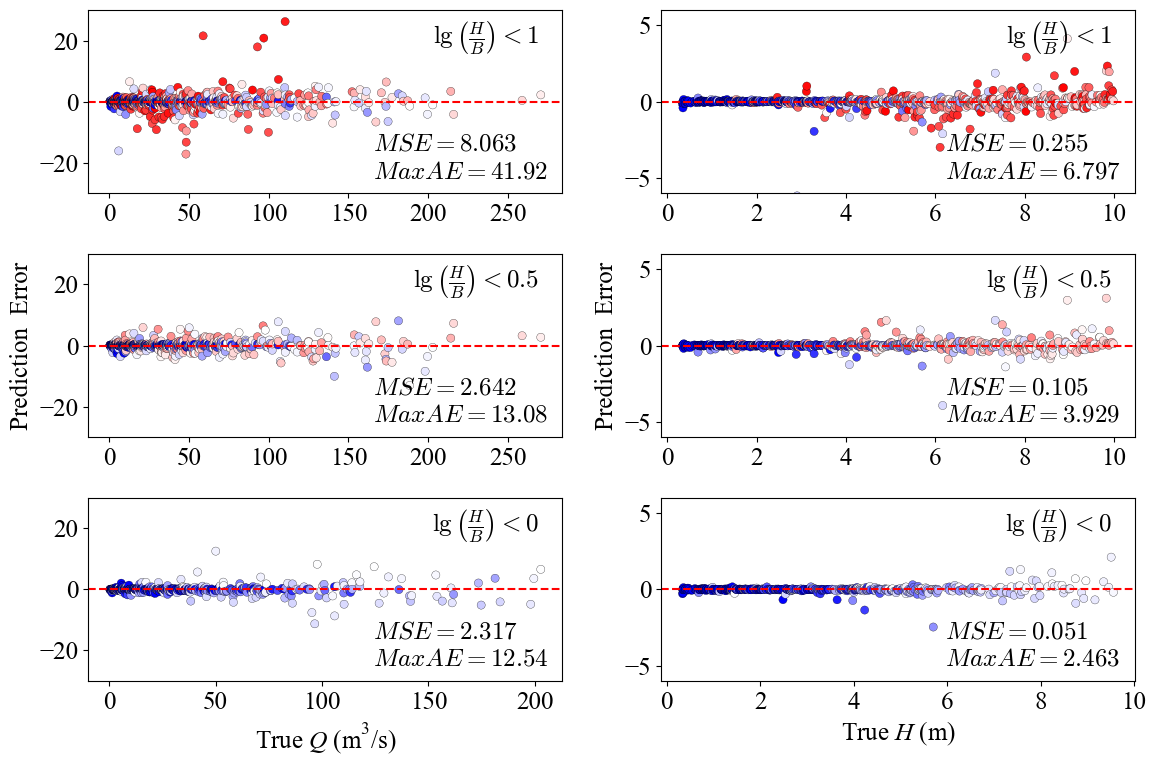

In [11]:
# Create tatle name
nameQ='Q'
SIQ = r'($\mathrm{m}^3/\mathrm{s}$)'
nameH='H'
SIH = '(m)'
nameV='V'
SIV = '(m/s)'

# Create a single figure with two columns
fig, axes = plt.subplots(3, 2, figsize=(12, 8), dpi=100, 
                        gridspec_kw={'width_ratios': [1, 1]})
plt.rcParams['font.size'] = 18
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'cm'

# Left column (first set of plots)
ploterror(Q1r1, Q1_predr1, getHoverB(z1r1), nameQ, SIQ, 
          tatel=r'$\lg\left(\frac{H}{B}\right) < 1$', ax=axes[0, 0], a=30)

ploterror(Q1r05, Q1_predr05, getHoverB(z1r05), nameQ, SIQ, 
          tatel=r'$\lg\left(\frac{H}{B}\right) < 0.5$', ax=axes[1, 0], a=30, labelleft=True)

ploterror(Q1r0, Q1_predr0, getHoverB(z1r0), nameQ, SIQ, 
          tatel=r'$\lg\left(\frac{H}{B}\right) < 0$', ax=axes[2, 0], a=30, labelbottom=True)

# Right column (second set of plots)
ploterror(H1r1,H1_predr1,getHoverB(z1r1),nameH,SIH,
          tatel=r'$\lg\left(\frac{H}{B}\right) < 1$',ax=axes[0, 1],a=6)

ploterror(H1r05,H1_predr05,getHoverB(z1r05),nameH,SIH,
          tatel=r'$\lg\left(\frac{H}{B}\right) < 0.5$',ax=axes[1, 1],labelleft=True,a=6)

ploterror(H1r0,H1_predr0,getHoverB(z1r0),nameH,SIH,
          tatel=r'$\lg\left(\frac{H}{B}\right) < 0$',ax=axes[2, 1],labelbottom = True,a=6)

plt.tight_layout()
# fig.savefig(save, dpi=500, bbox_inches='tight', pad_inches=0.1)
plt.show()


<function matplotlib.pyplot.show(close=None, block=None)>

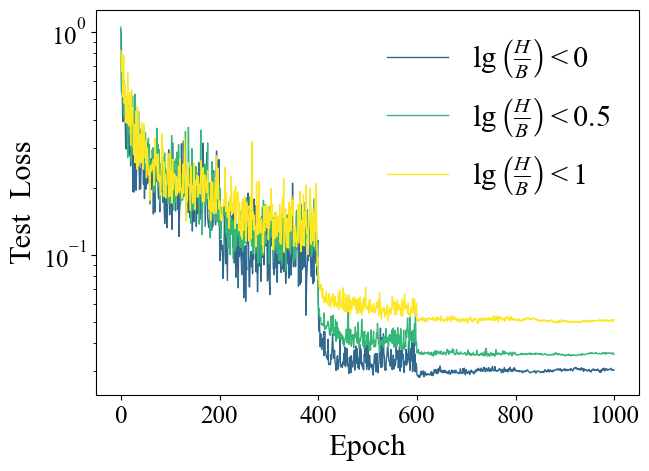

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'

fig = plt.figure(figsize=(7, 5), dpi=100)  

plt.tick_params(axis='both', which='major', labelsize=18)
plt.xticks(fontname='Times New Roman')
plt.yticks(fontname='Times New Roman')
NAMEbe = 'ResNetdatapro3S_20_hoverb'
cmap = plt.colormaps.get_cmap('viridis')

NAME=NAMEbe+str(0)
lossName = NAME +'_loss.log'
data=np.loadtxt(lossName,unpack=True)
color = cmap(1 / 3)
plt.semilogy(data[2],color=color,lw=1,label=r'$\lg\left(\frac{H}{B}\right) < 0$')

NAME=NAMEbe+str(0.5)
lossName = NAME +'_loss.log'
data=np.loadtxt(lossName,unpack=True)
color = cmap(2 / 3)
plt.semilogy(data[2],color=color,lw=1,label=r'$\lg\left(\frac{H}{B}\right) < 0.5$')

NAME=NAMEbe+str(1)
lossName = NAME +'_loss.log'
data=np.loadtxt(lossName,unpack=True)
color = cmap(3 / 3)
plt.semilogy(data[2],color=color,lw=1,label=r'$\lg\left(\frac{H}{B}\right) < 1$')

plt.legend(fontsize=22,frameon=False,facecolor='white', edgecolor='none',loc='upper right',ncol=1)

# plt.title("Test Loss Curve",fontsize=22,fontname='Times New Roman')
plt.xlabel("Epoch",fontsize=22,fontname='Times New Roman')
plt.ylabel("Test  Loss",fontsize=22,fontname='Times New Roman')
# fig.savefig(save, dpi=1500, bbox_inches='tight', pad_inches=0.1)
plt.show